## Random forest

### Library for Random forest

In [ ]:
    import PySimpleGUI as sg
    import pandas as pd
    import numpy as np
    import seaborn as sns
    import matplotlib.pyplot as plt
    from matplotlib import cm, colors
    from matplotlib.patches import Ellipse
    import matplotlib.transforms as transforms
    from mpl_toolkits import mplot3d
    from statannot import add_stat_annotation
    from mlxtend.plotting import plot_pca_correlation_graph
    from scipy.cluster.hierarchy import cophenet, dendrogram, linkage, set_link_color_palette
    from scipy.cluster.vq import kmeans
    from scipy.spatial.distance import cdist, pdist, squareform
    from sklearn.preprocessing import LabelEncoder, StandardScaler
    from sklearn.decomposition import PCA
    from sklearn.manifold import TSNE
    from sklearn.metrics import silhouette_samples, silhouette_score
    from sklearn.impute import SimpleImputer
    from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN, MeanShift, estimate_bandwidth
    from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
    from sklearn.neighbors import KNeighborsClassifier
    from sklearn.svm import SVC
    from sklearn.model_selection import StratifiedShuffleSplit, StratifiedKFold, GridSearchCV, train_test_split, learning_curve, validation_curve
    from sklearn.multiclass import OneVsRestClassifier
    from sklearn.ensemble import IsolationForest
    from sklearn.metrics import roc_curve, confusion_matrix

### Preparation of the data

In [ ]:
# Prepare data for Random Forest
X = df_WT_pooled  # Features: all the synaptic properties
y = pd.Series(hc_labels_umap)  # Target: cluster labels from hierarchical clustering, converted to pandas Series

print(f"Dataset shape: {X.shape}")
print(f"Number of clusters: {len(np.unique(y))}")
print(f"Cluster distribution: {np.bincount(y)[1:]}")  # Skip index 0 since clusters start from 1

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)


Dataset shape: (182, 13)
Number of clusters: 5
Cluster distribution: [ 8 32 85 17 40]


### Parameters

In [ ]:
# Define Random Forest model with hyperparameter grid
model = RandomForestClassifier(n_estimators=20, max_leaf_nodes=3)
model_name = 'RandForestClass'

param_grid = {"max_depth": np.arange(2,6),
                "min_samples_split": np.arange(2,11),
                "min_samples_leaf": np.arange(2,11)}

params_val = ['n_estimators',
                'max_depth',
                'max_leaf_nodes',
                'min_samples_split',
                'min_samples_leaf']

confusion_mats_all = []
cross_val_score_all = []
test_score_all = []
ALL_TRAIN, ALL_VAL = [],[]
TRAIN_SCORE_MEAN, TEST_SCORE_MEAN = [],[]
TRAIN_SCORE_STD, TEST_SCORE_STD = [],[]

### Find best hyper parameters - Definition
This section performs hyperparameter optimization for a Random Forest classifier to find the best parameters that minimize overfitting while maintaining good performance.

In [ ]:
def find_best_hyperparameters(model, model_name, param_grid, params_val, X_train, y_train, X_test, y_test, cross_val):
       
    fpr = {}
    tpr = {}
    thresh ={}
    TRAIN, VAL = [],[]
    
   
    grid = GridSearchCV(model, param_grid, n_jobs=-1, cv = cross_val)
    grid.fit(X_train, y_train)
    pred_prob = grid.predict_proba(X_test)
    
    cross_val_score = grid.best_score_
    print('------------------')
    print('Best model score')
    print(cross_val_score)
    print('Best model parameters')
    print(grid.best_estimator_)
    
    modell = grid.best_estimator_
    
    n_class = np.unique(y_train).size

    fig_roc_learn, ax = plt.subplots(1, 2, figsize=(14,4), tight_layout=True)
    
    # Convert multiclass to binary for ROC curve computation
    from sklearn.preprocessing import label_binarize
    y_test_bin = label_binarize(y_test, classes=np.unique(y_train))
    
    for i in range(n_class):   
        if np.sum(y_test_bin[:, i]) > 0:  # Only compute ROC if class has positive samples
            fpr[i], tpr[i], thresh[i] = roc_curve(y_test_bin[:, i], pred_prob[:,i])
            ax[0].plot(fpr[i], tpr[i], linestyle='--', alpha=0.5, label=f'Class {i+1} vs Rest')
    
    ax[0].set_title(f'Multiclass ROC curve\n {modell}')
    ax[0].set_xlabel('False Positive Rate')
    ax[0].set_ylabel('True Positive rate')
    ax[0].legend()
        
    train_sizes, train_scores, test_scores = learning_curve(modell, X_train, y_train, train_sizes=np.linspace(0.1, 1., 20), cv=cross_val)
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)
    
    ax[1].set_title('Learning curve')
    ax[1].set_xlabel("Train samples")
    ax[1].set_ylabel("Score")
    ax[1].grid()

    ax[1].fill_between(train_sizes, train_scores_mean - train_scores_std, train_scores_mean + train_scores_std, alpha=0.1, color="r")
    ax[1].fill_between(train_sizes, test_scores_mean - test_scores_std, test_scores_mean + test_scores_std, alpha=0.1, color="g")
    ax[1].plot(train_sizes, train_scores_mean, 'o-', color="r", label="Train score")
    ax[1].plot(train_sizes, test_scores_mean, 'o-', color="g", label="Validation score")
    ax[1].legend(loc="best")
    
    
    k = np.arange(1,61)
    fig_val, ax_val = plt.subplots(1, len(params_val), figsize=(16,4), tight_layout=True)
    ax_val[1].set_title('Validation curves')
    for i in range(len(params_val)):
        train_score, val_score = validation_curve(estimator=model, X=X_train, y=y_train, param_name=params_val[i], param_range=k, cv=cross_val)
        train_score_mean = np.mean(train_score, axis=1)
        val_score_mean = np.mean(val_score, axis=1)
        TRAIN.append(train_score_mean)
        VAL.append(val_score_mean)
        
        ax_val[i].plot(k, train_score_mean, 'r', marker='o', label='Training')
        ax_val[i].plot(k, val_score_mean, 'b', marker='o', label='Validation')
        ax_val[i].set_xlabel(params_val[i])
        ax_val[i].set_ylabel('Score')
        ax_val[i].set_ylim(0,1)
        ax_val[i].grid()
        ax_val[i].legend()
    
    return modell, cross_val_score, train_sizes, train_scores_mean, test_scores_mean, train_scores_std, test_scores_std, TRAIN, VAL, fig_roc_learn, fig_val

### Find best hyper parameters - Application

------------------
Best model score
0.7655172413793103
Best model parameters
RandomForestClassifier(max_depth=5, max_leaf_nodes=3, min_samples_leaf=5,
                       n_estimators=20)
Test score TRIAL 0; SPLIT 1
0.7837837837837838
------------------
Test score TRIAL 0; SPLIT 1
0.7837837837837838
------------------
------------------
Best model score
0.8137931034482758
Best model parameters
RandomForestClassifier(max_depth=4, max_leaf_nodes=3, min_samples_leaf=6,
                       min_samples_split=8, n_estimators=20)
------------------
Best model score
0.8137931034482758
Best model parameters
RandomForestClassifier(max_depth=4, max_leaf_nodes=3, min_samples_leaf=6,
                       min_samples_split=8, n_estimators=20)
Test score TRIAL 0; SPLIT 2
0.6486486486486487
------------------
Test score TRIAL 0; SPLIT 2
0.6486486486486487
------------------
------------------
Best model score
0.7806896551724138
Best model parameters
RandomForestClassifier(max_depth=5, max_leaf

C:\Users\Anthime.PERROT\AppData\Local\Temp\ipykernel_1941800\2521009265.py:44: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`).
  fig_conf, ax_ = plt.subplots()


------------------
Best model score
0.7802298850574714
Best model parameters
RandomForestClassifier(max_depth=3, max_leaf_nodes=3, min_samples_leaf=5,
                       min_samples_split=6, n_estimators=20)
Test score TRIAL 1; SPLIT 3
0.7777777777777778
------------------
Test score TRIAL 1; SPLIT 3
0.7777777777777778
------------------
------------------
Best model score
0.7602298850574714
Best model parameters
RandomForestClassifier(max_depth=3, max_leaf_nodes=3, min_samples_leaf=6,
                       min_samples_split=10, n_estimators=20)
------------------
Best model score
0.7602298850574714
Best model parameters
RandomForestClassifier(max_depth=3, max_leaf_nodes=3, min_samples_leaf=6,
                       min_samples_split=10, n_estimators=20)
Test score TRIAL 1; SPLIT 4
0.8055555555555556
------------------
Test score TRIAL 1; SPLIT 4
0.8055555555555556
------------------
------------------
Best model score
0.7806896551724138
Best model parameters
RandomForestClassifie

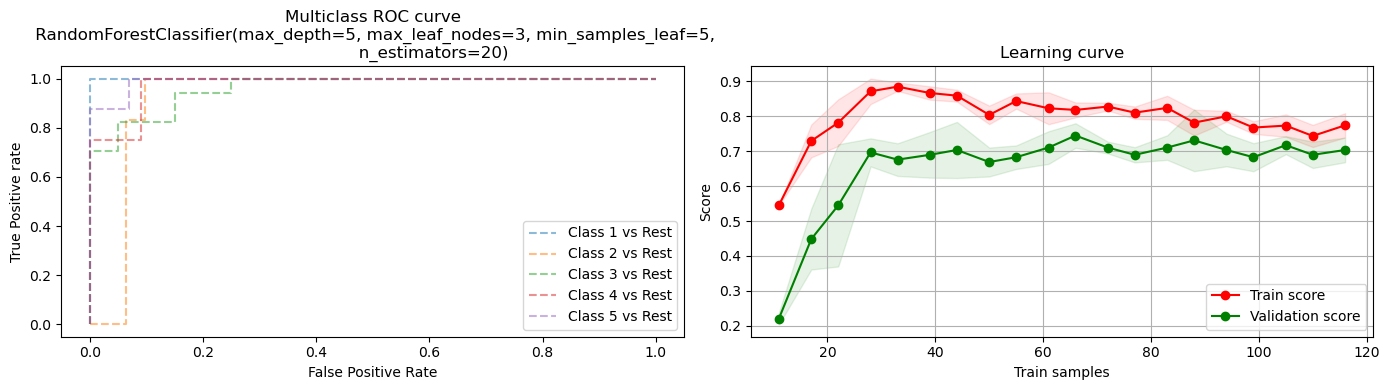

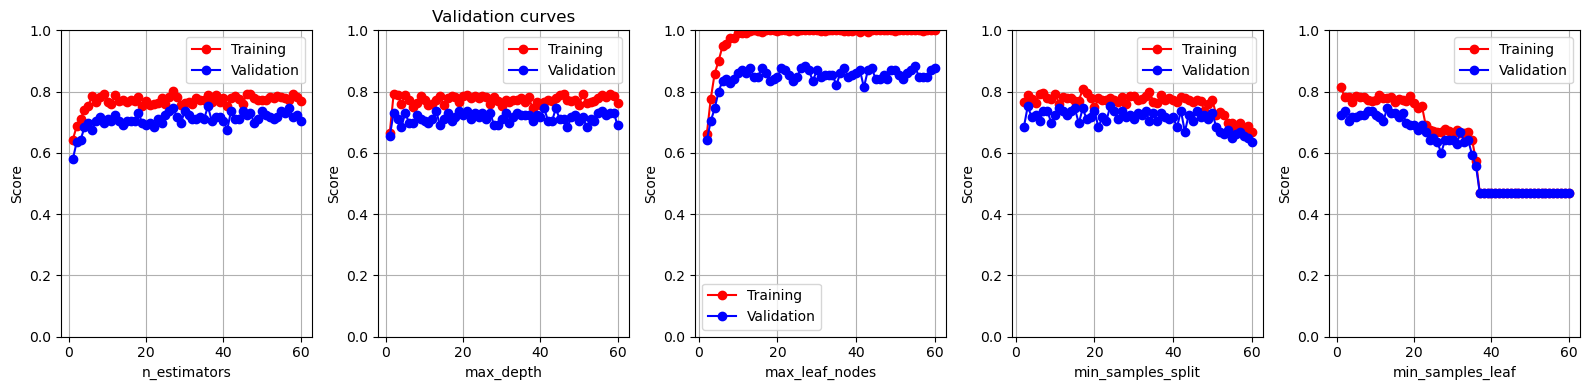

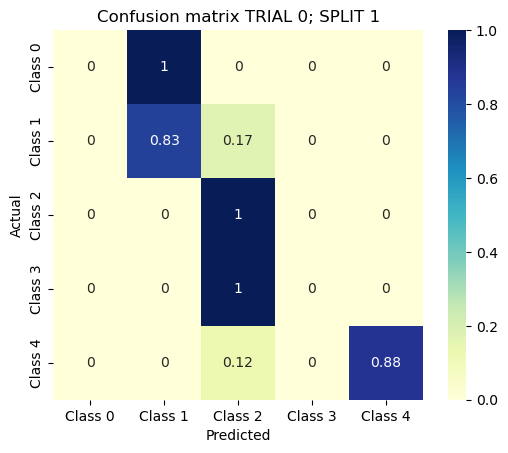

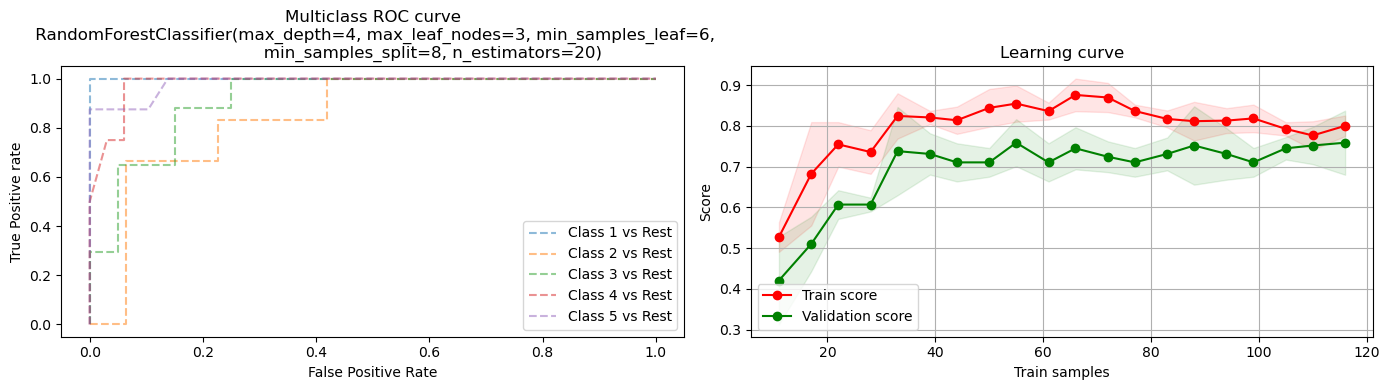

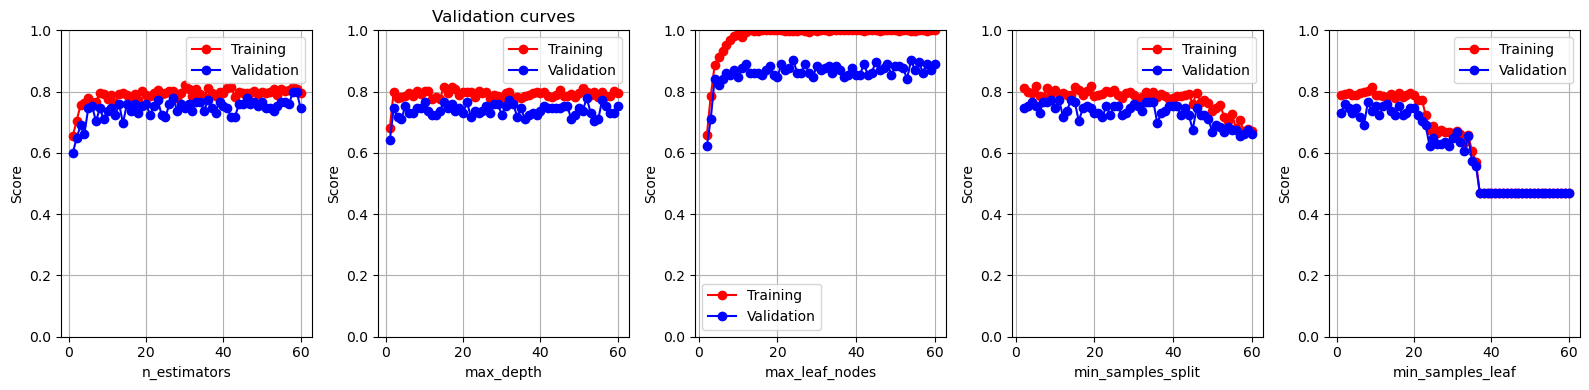

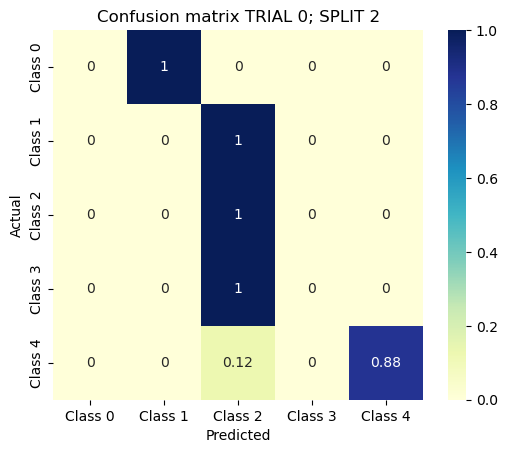

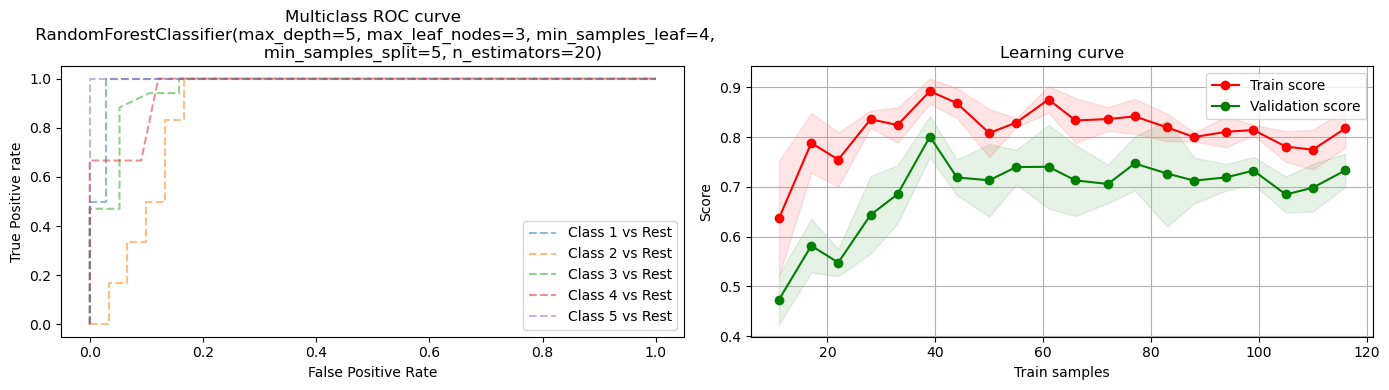

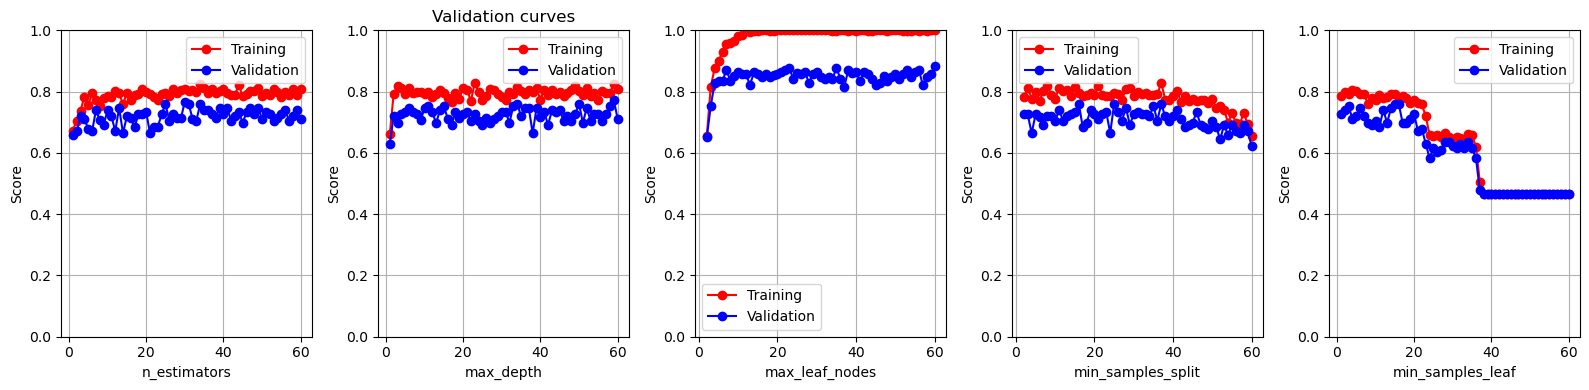

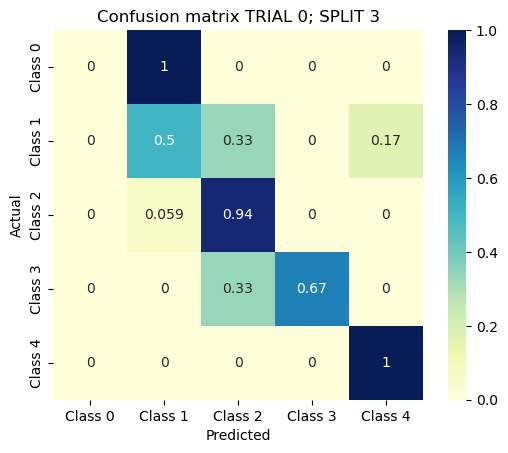

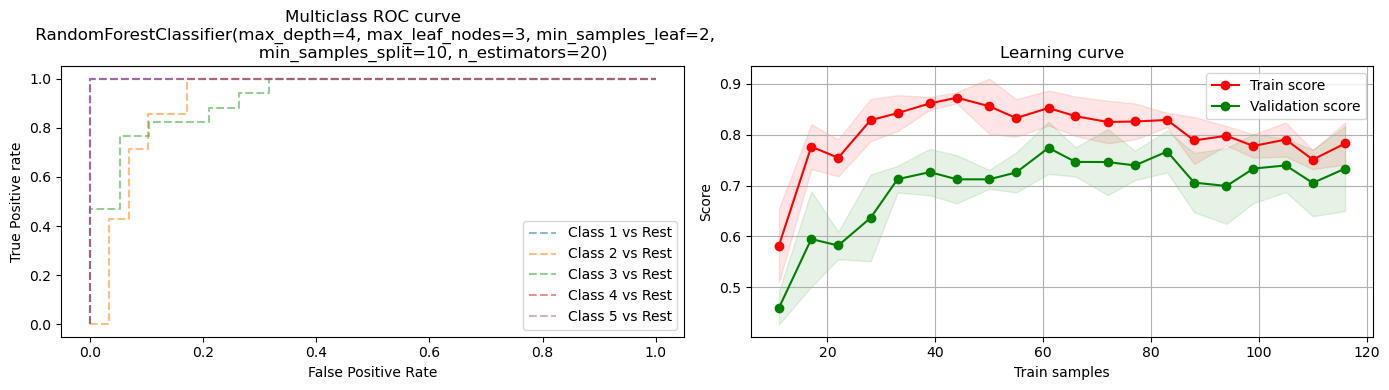

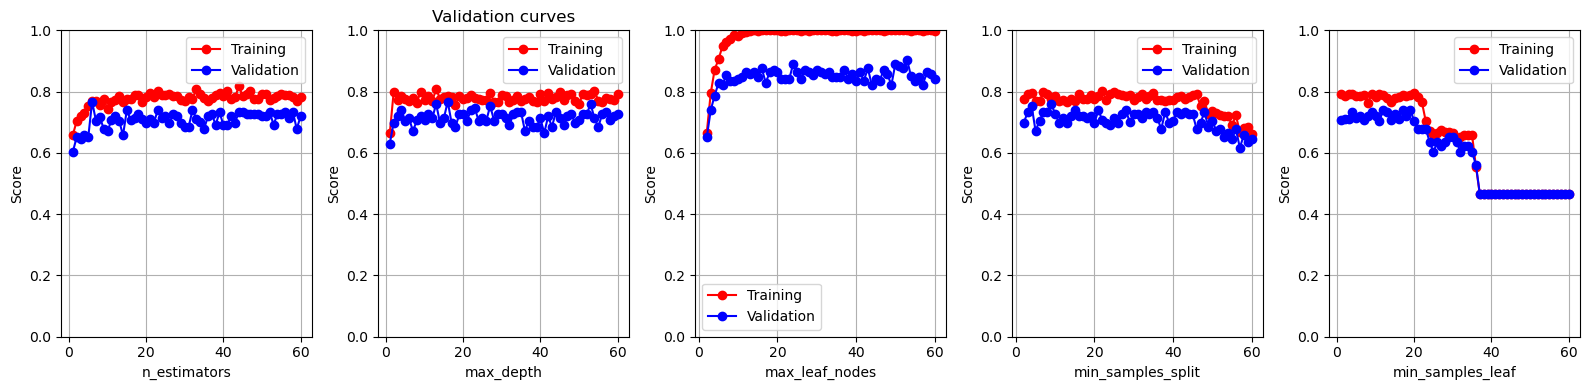

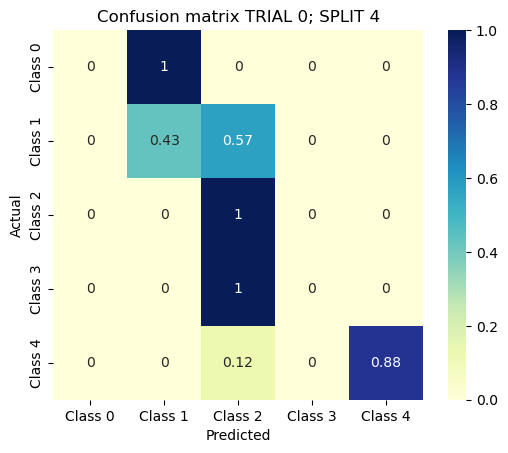

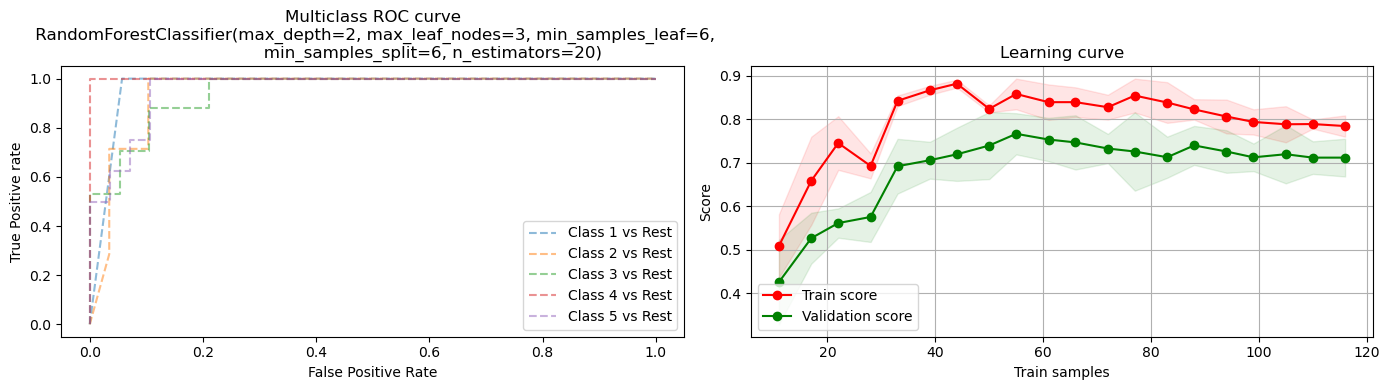

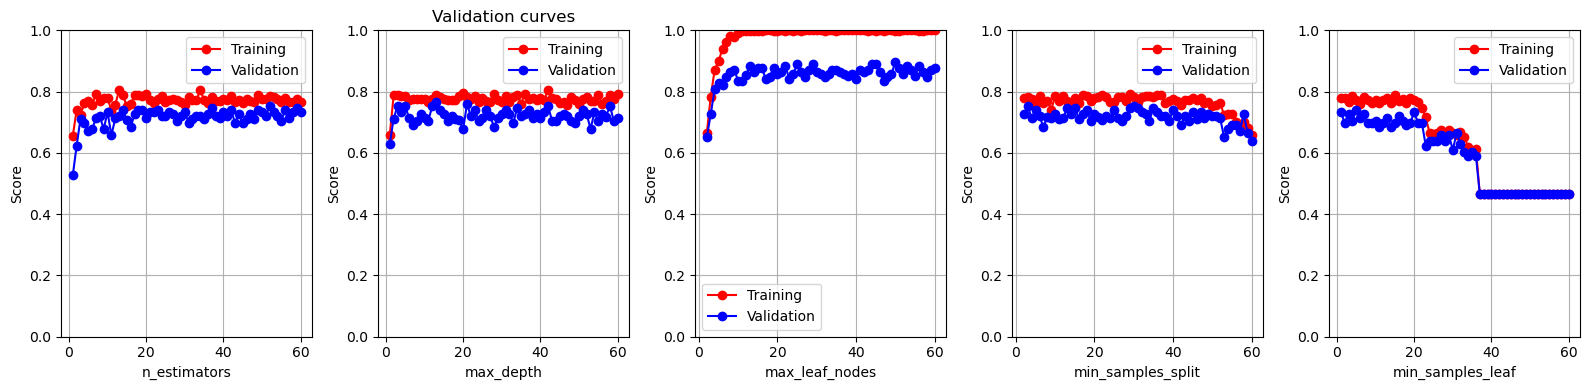

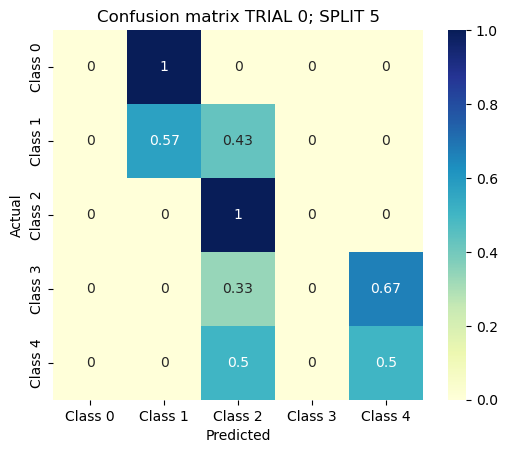

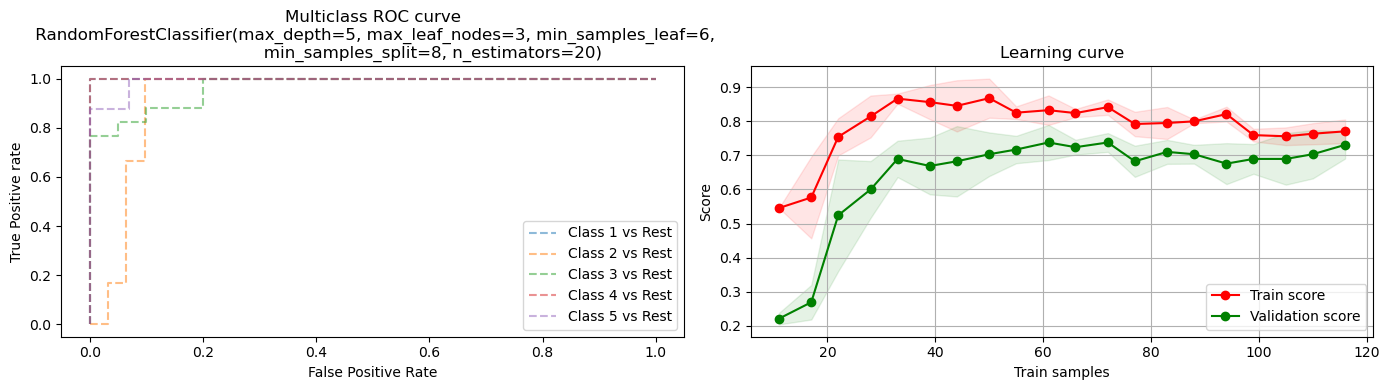

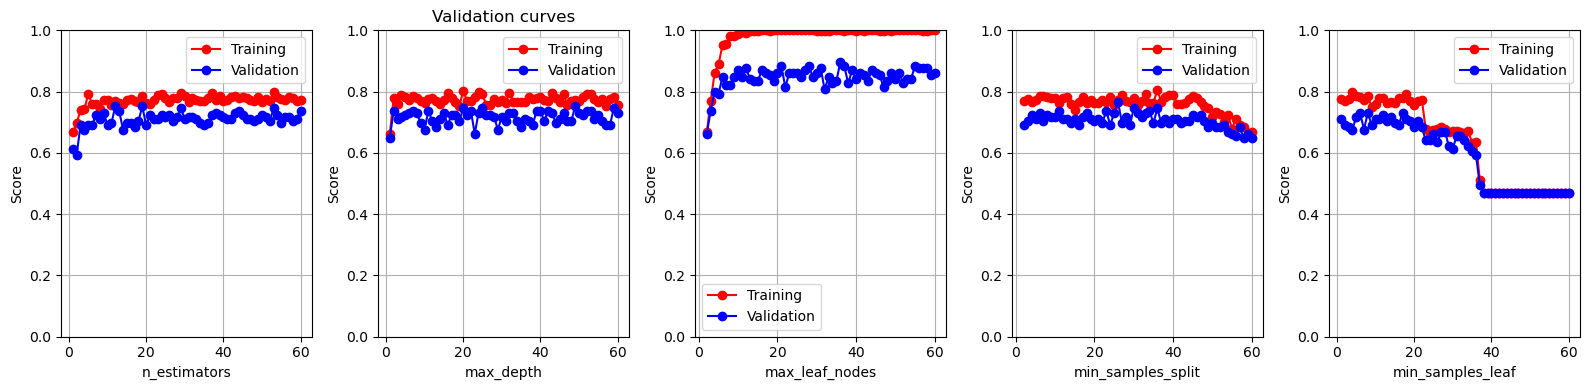

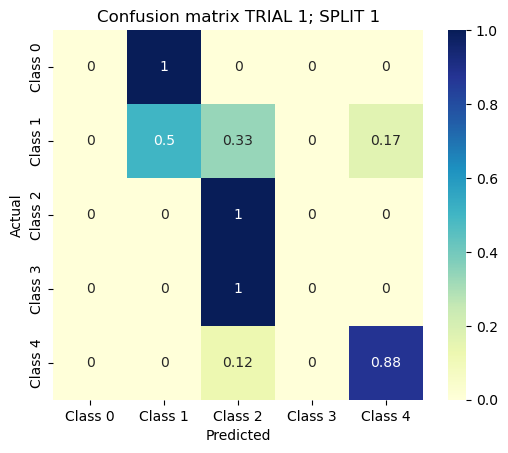

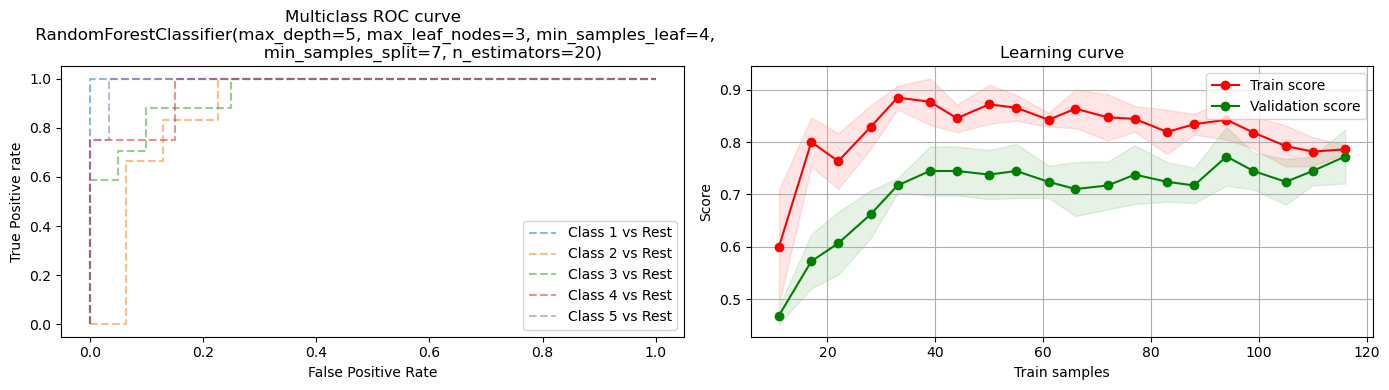

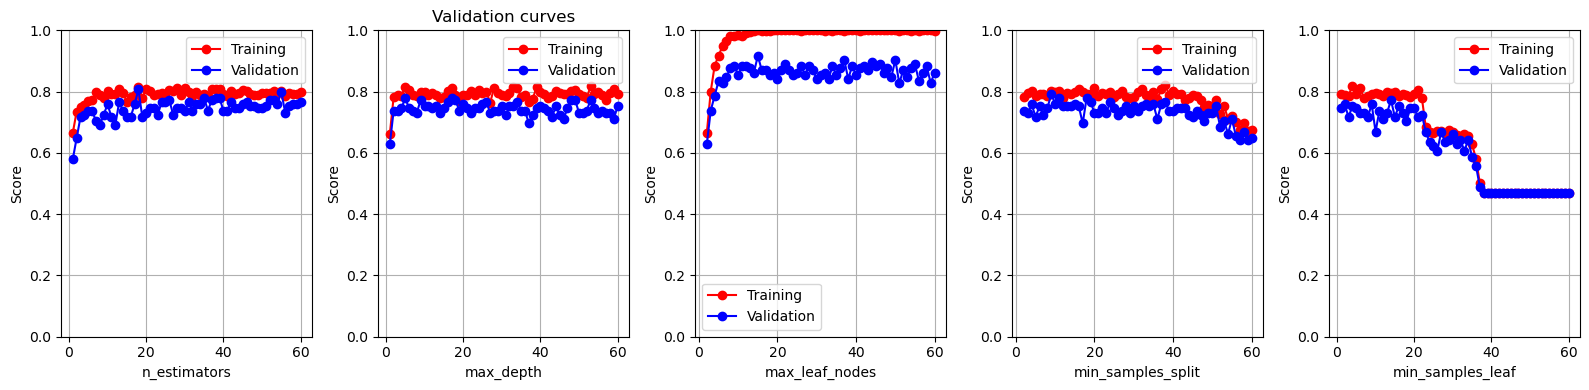

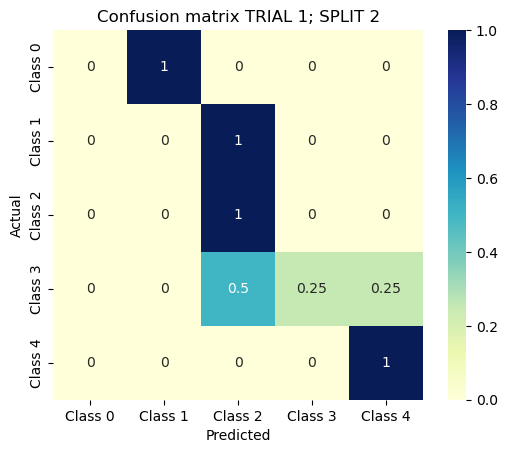

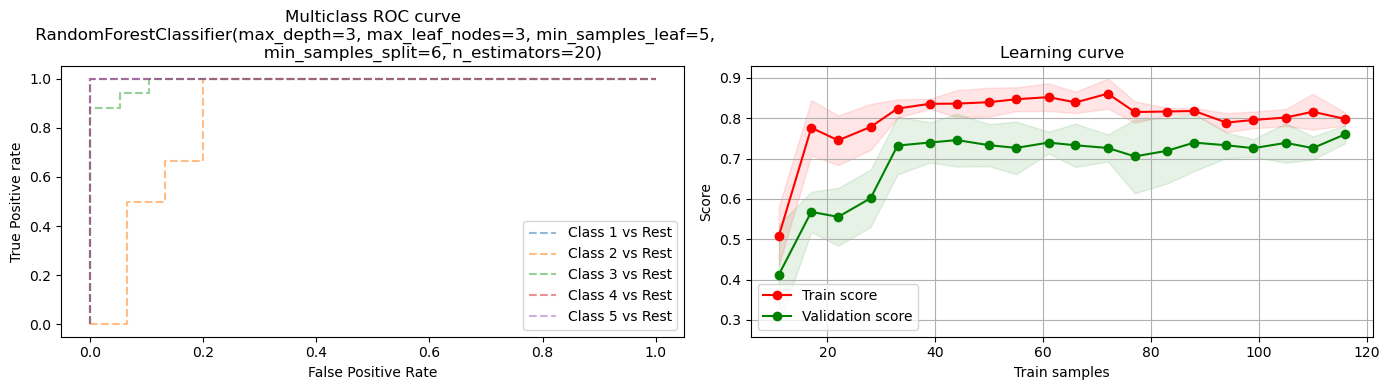

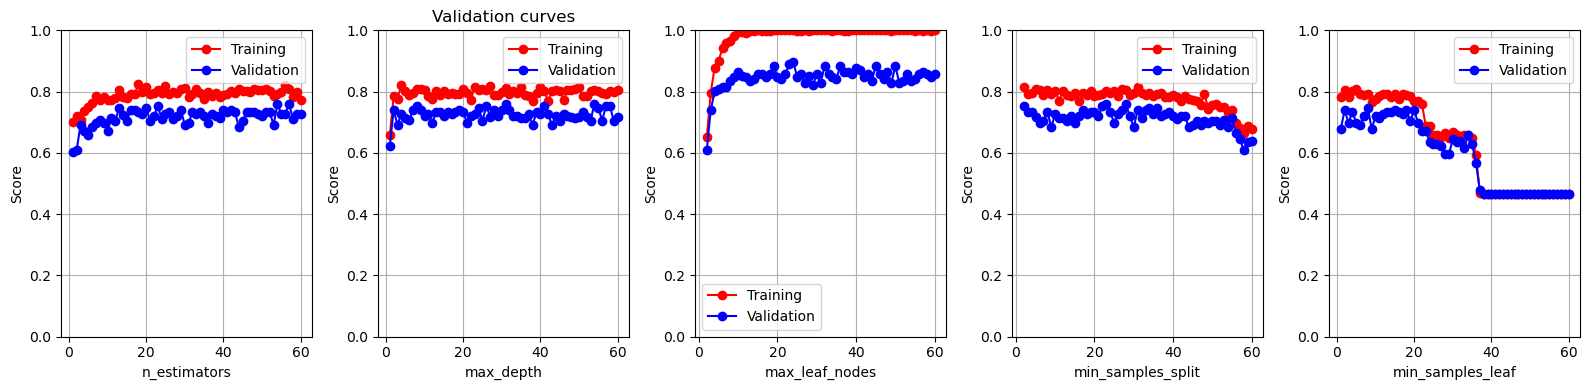

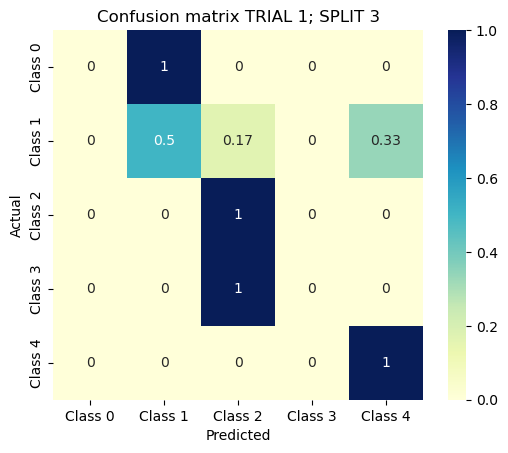

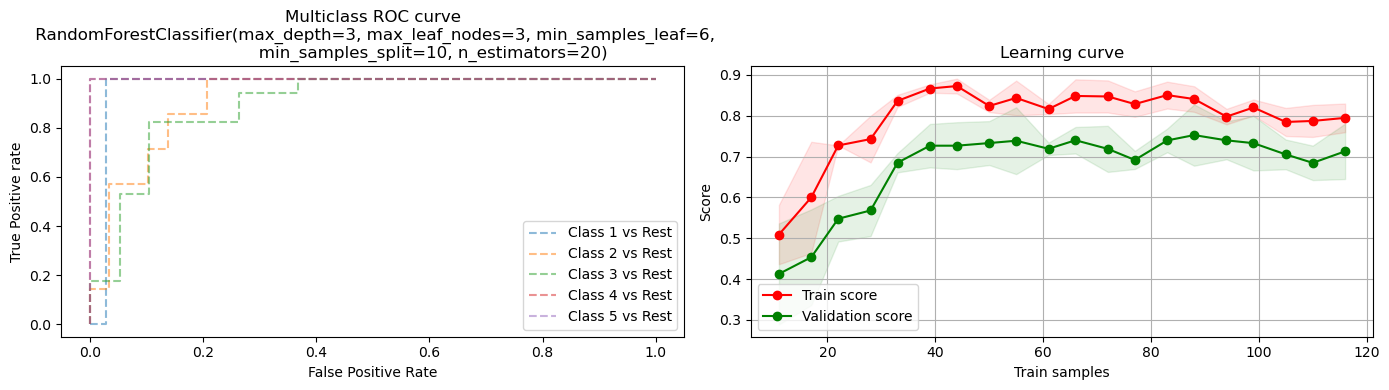

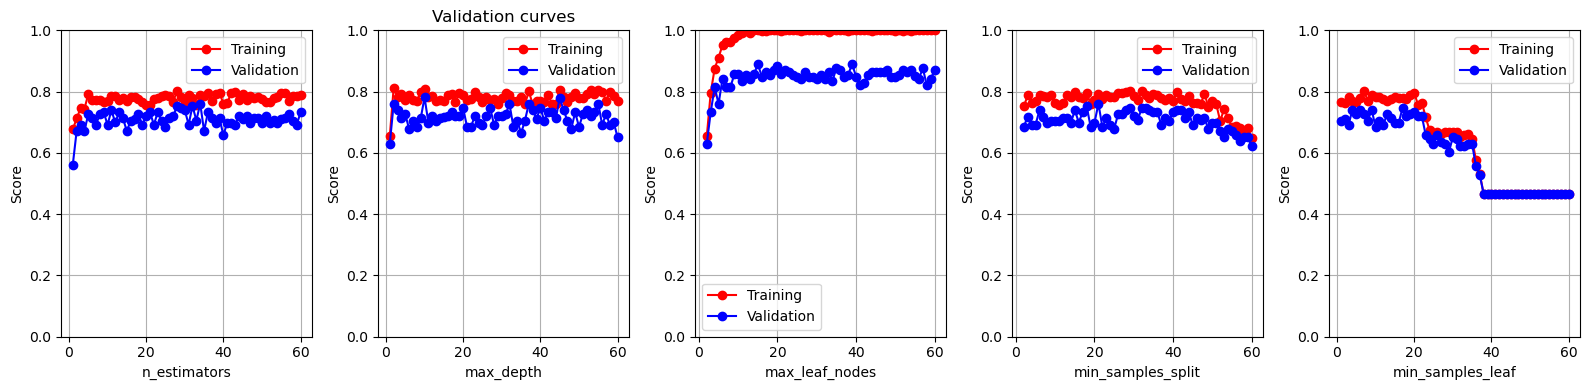

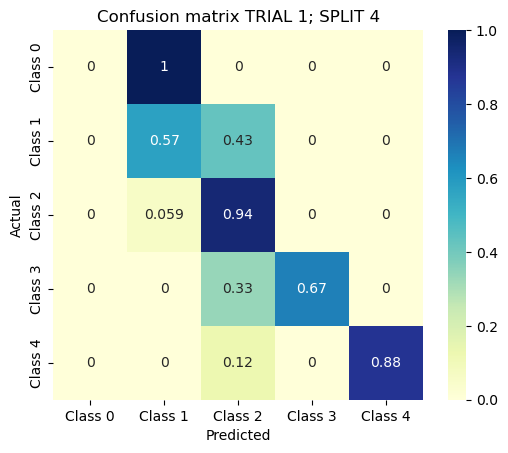

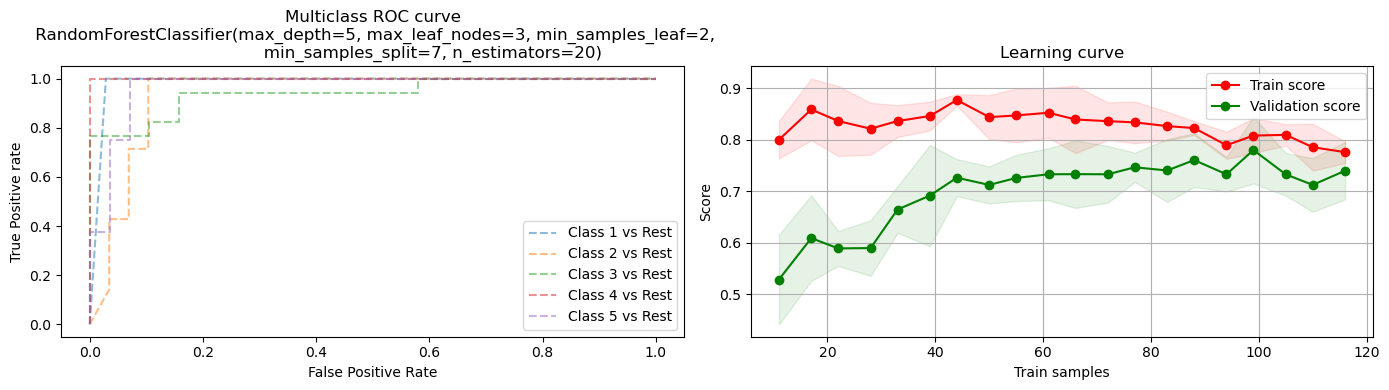

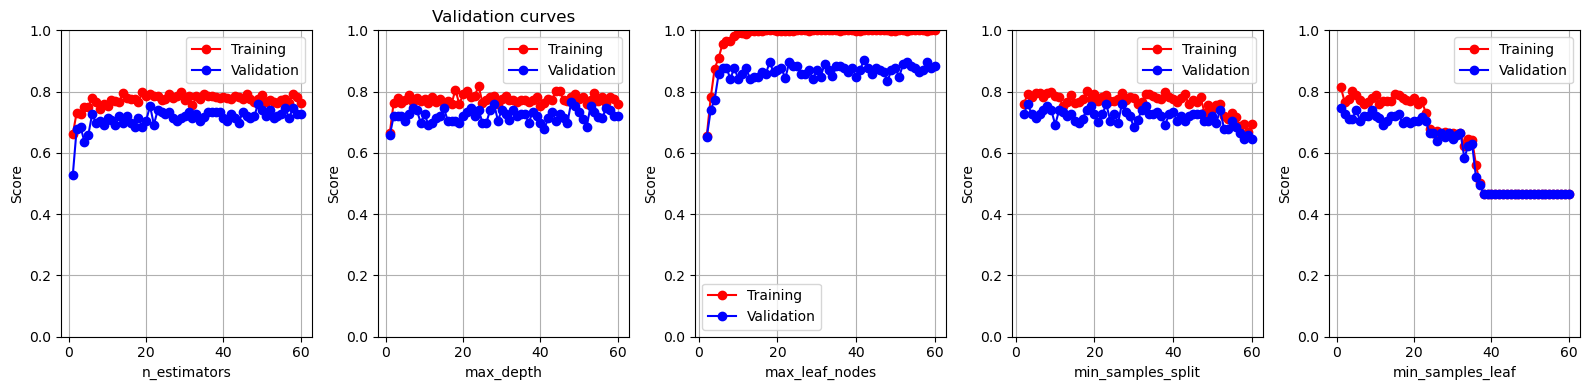

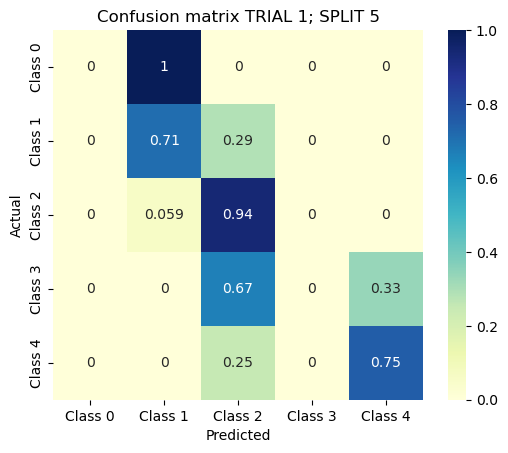

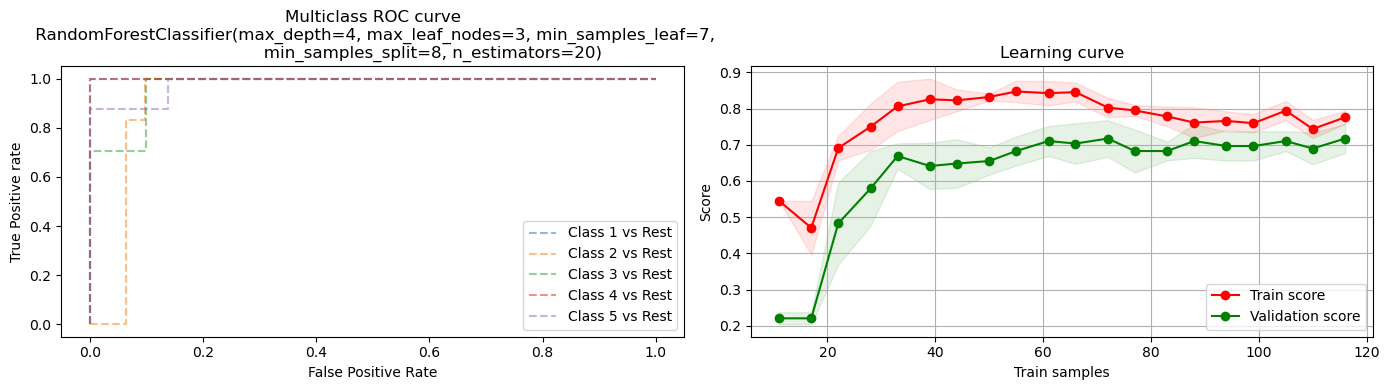

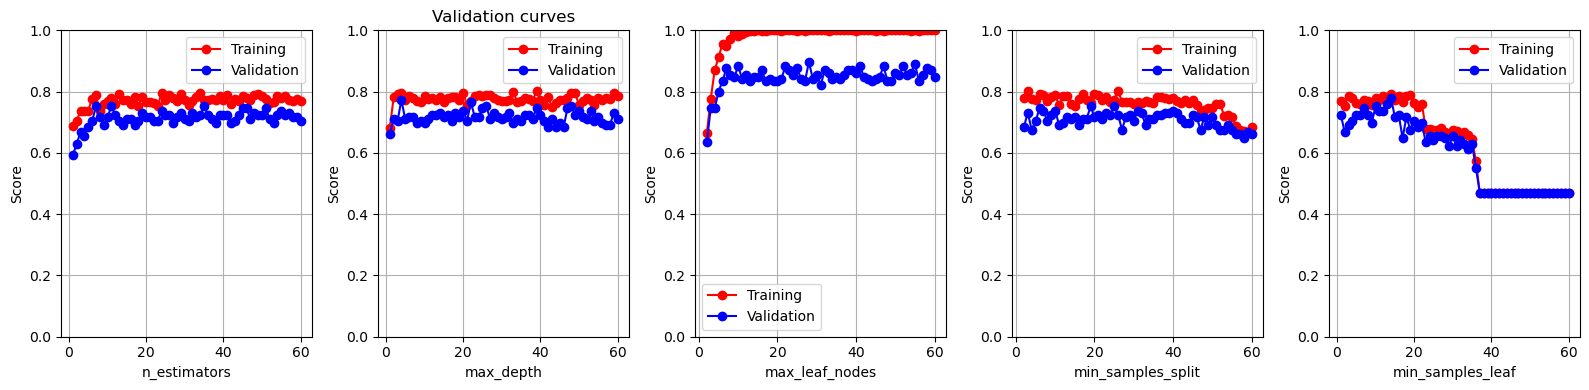

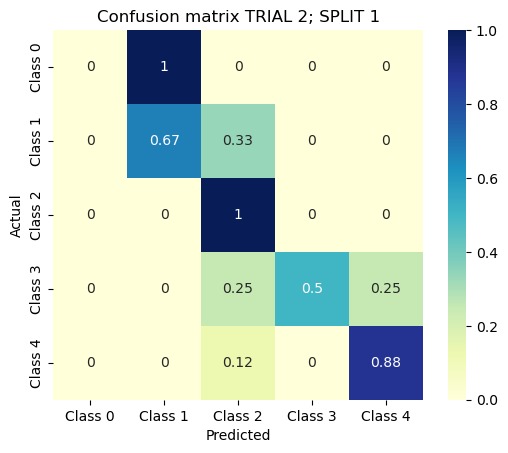

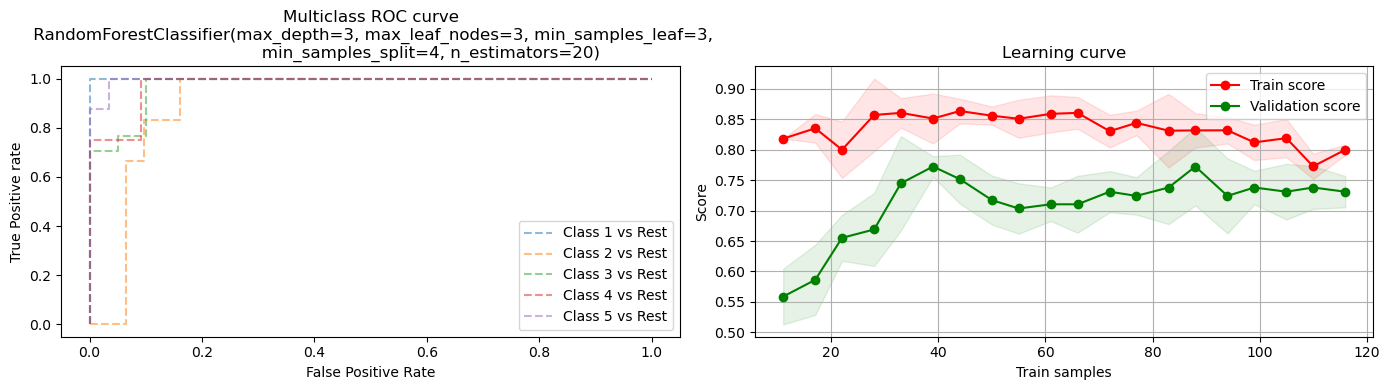

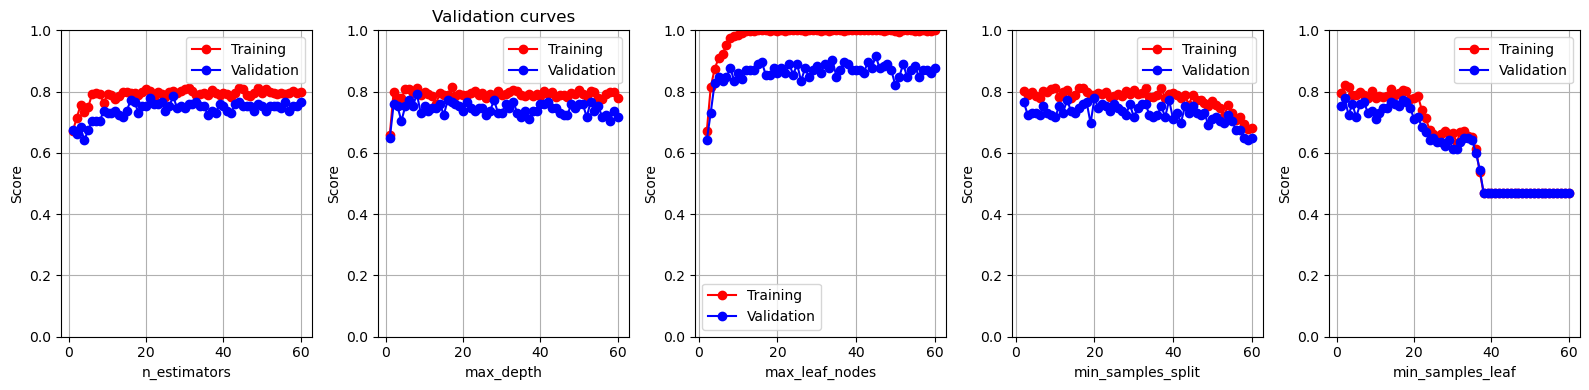

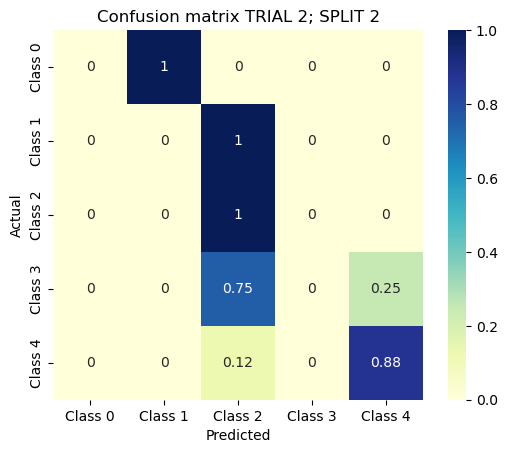

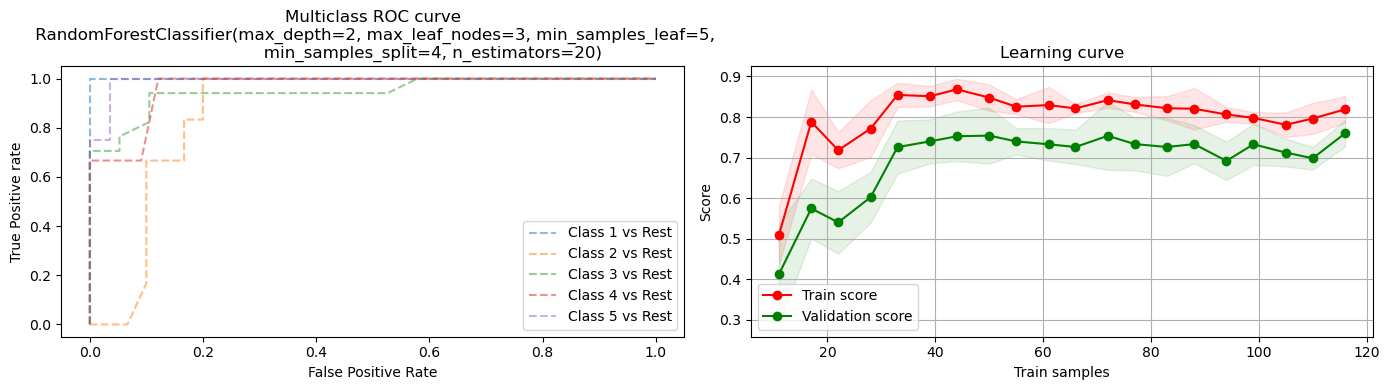

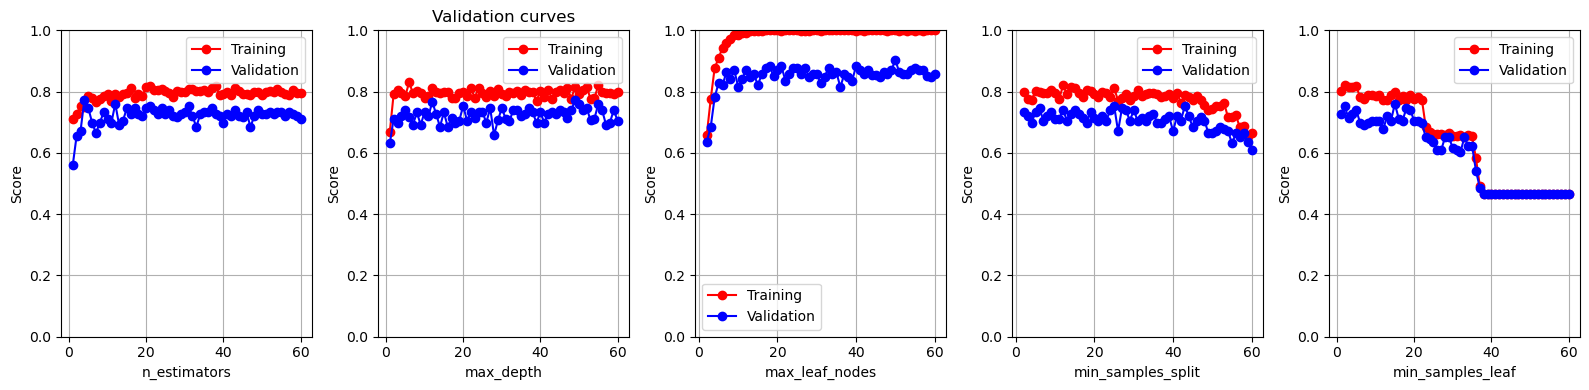

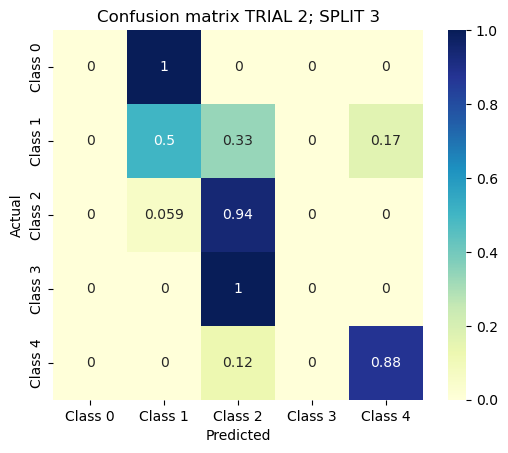

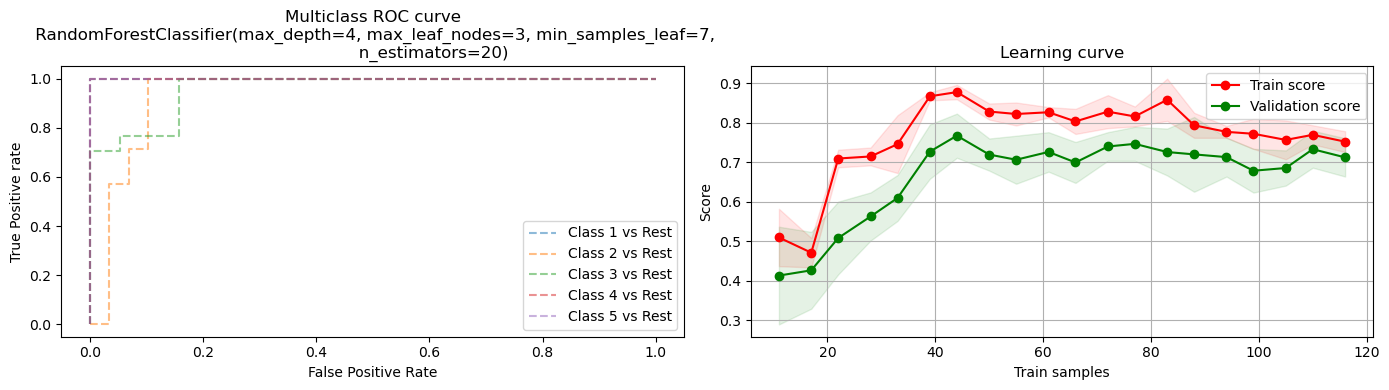

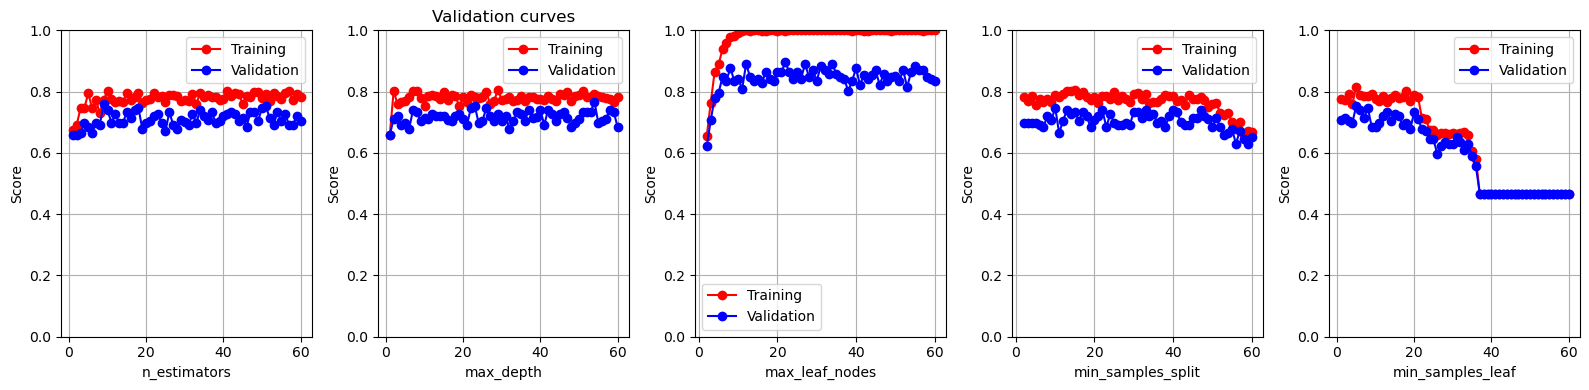

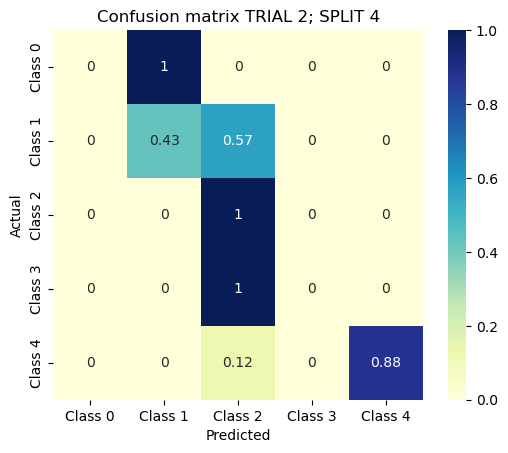

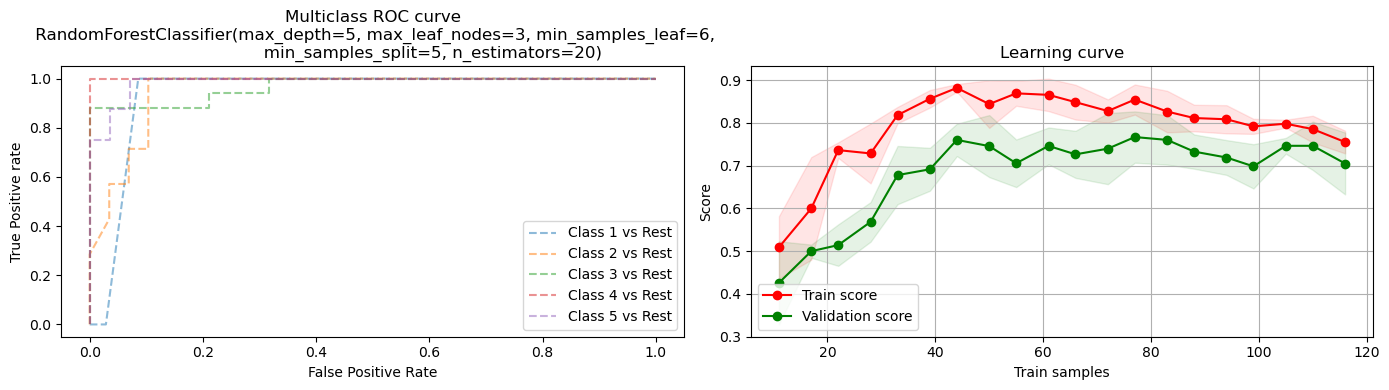

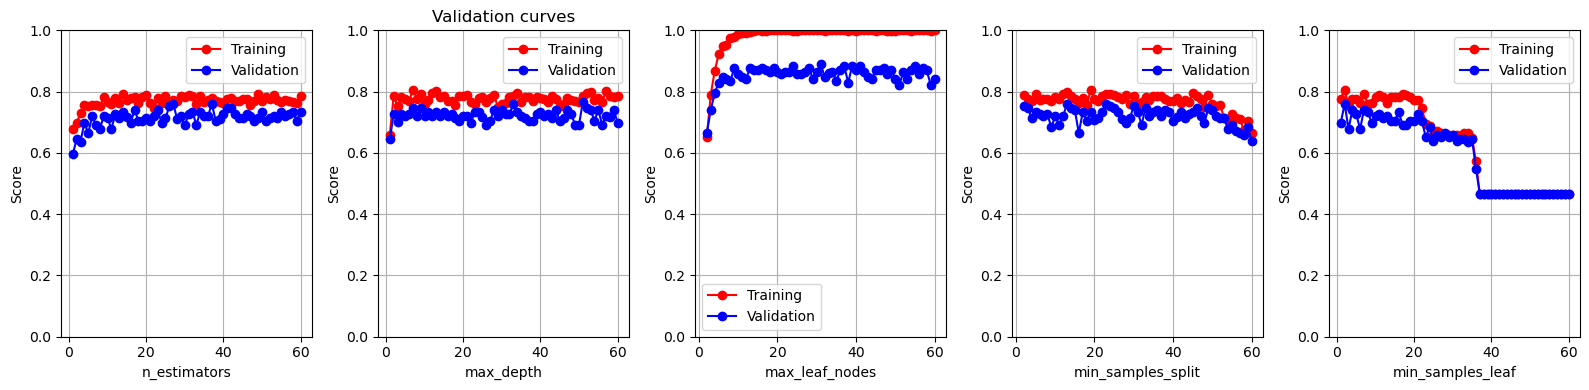

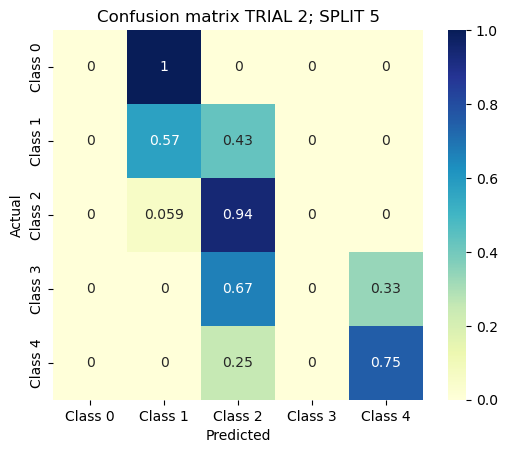

In [ ]:
#splitting = StratifiedShuffleSplit(n_splits = int(analysis_value['Split']), test_size = float(analysis_value['Test_size']))
splitting = StratifiedKFold(n_splits = int(5)) #5 is the value of split line 1043

confusion_mats_all = []
cross_val_score_all = []
test_score_all = []
ALL_TRAIN, ALL_VAL = [],[]
TRAIN_SCORE_MEAN, TEST_SCORE_MEAN = [],[]
TRAIN_SCORE_STD, TEST_SCORE_STD = [],[]

for i in range(int(3)): #10 normally, but here we use 3 for testing purposes
    for (train, test), j in zip(splitting.split(X, y), range(1, int(5)+1)): #5 is the value of split line 1043
        X_train, X_test = X.iloc[train], X.iloc[test]
        y_train, y_test = y.iloc[train], y.iloc[test]
        
        modell, cross_val_score, train_sizes, train_scores_mean, test_scores_mean, train_scores_std, test_scores_std, TRAIN, VAL, fig_roc_learn, fig_val = find_best_hyperparameters(model,
                                                                                                                                                                                        model_name,
                                                                                                                                                                                        param_grid,
                                                                                                                                                                                        params_val,
                                                                                                                                                                                        X_train, y_train,
                                                                                                                                                                                        X_test,
                                                                                                                                                                                        y_test,
                                                                                                                                                                                        splitting)
        ALL_TRAIN.append(TRAIN)
        ALL_VAL.append(VAL)
        TRAIN_SCORE_MEAN.append(train_scores_mean)
        TEST_SCORE_MEAN.append(test_scores_mean)
        TRAIN_SCORE_STD.append(train_scores_std)
        TEST_SCORE_STD.append(test_scores_std)
        
        cross_val_score_all.append(cross_val_score)
        
        print(f'Test score TRIAL {i}; SPLIT {j}')
        print(modell.score(X_test, y_test))
        print('------------------')

        matrix = confusion_matrix(y_test, modell.predict(X_test), normalize = 'true')
        
        confusion_mats_all.append(pd.DataFrame(matrix))
        test_score = modell.score(X_test, y_test)
        test_score_all.append(test_score)
        
        ## FIGURE Confusion matrix
        fig_conf, ax_ = plt.subplots()
        sns.heatmap(pd.DataFrame(matrix), cmap='YlGnBu', vmin=0., vmax=1.,
                    xticklabels=[f'Class {i}' for i in range(len(np.unique(y)))],
                    yticklabels=[f'Class {i}' for i in range(len(np.unique(y)))],
                    ax=ax_, annot=True, square=True)
        ax_.set_xlabel('Predicted')
        ax_.set_ylabel('Actual')
        ax_.set_title(f'Confusion matrix TRIAL {i}; SPLIT {j}')
        
        ## SAVE FIGURES
        #fig_roc_learn.savefig(f'{saving_path}\LC_Trial{i}_Split{j}.pdf')
        #fig_val.savefig(f'{saving_path}\VC_Trial{i}_Split{j}.pdf')
        #fig_conf.savefig(f'{saving_path}\CM_Trial{i}_Split{j}.pdf')
    
confusion_mat_final = pd.concat(confusion_mats_all).groupby(level=0).mean()
print(f'Total_score: {np.mean(test_score_all)}')

Using zero_method  pratt
Cross-val scores v.s. Test scores: Wilcoxon test (paired samples) with Bonferroni correction, P_val=6.104e-05 stat=0.000e+00


c:\Users\Anthime.PERROT\Anaconda3\envs\Work_save\lib\site-packages\seaborn\categorical.py:470: FutureWarning: iteritems is deprecated and will be removed in a future version. Use .items instead.
  plot_data = [np.asarray(s, float) for k, s in iter_data]
c:\Users\Anthime.PERROT\Anaconda3\envs\Work_save\lib\site-packages\seaborn\categorical.py:470: FutureWarning: iteritems is deprecated and will be removed in a future version. Use .items instead.
  plot_data = [np.asarray(s, float) for k, s in iter_data]


(0.0, 1.0)

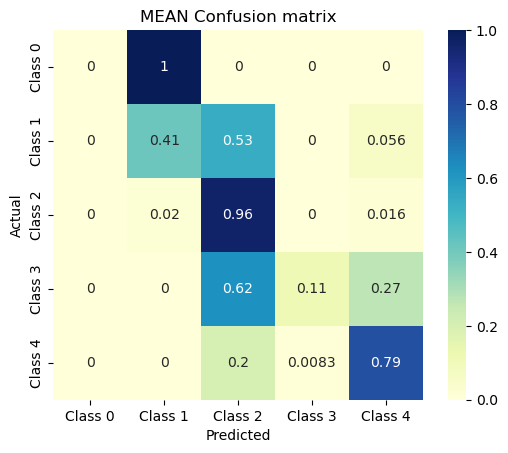

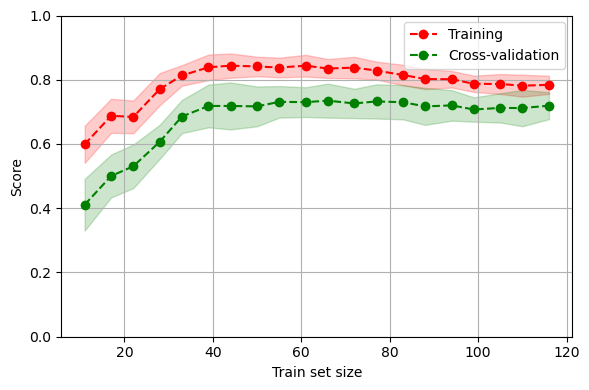

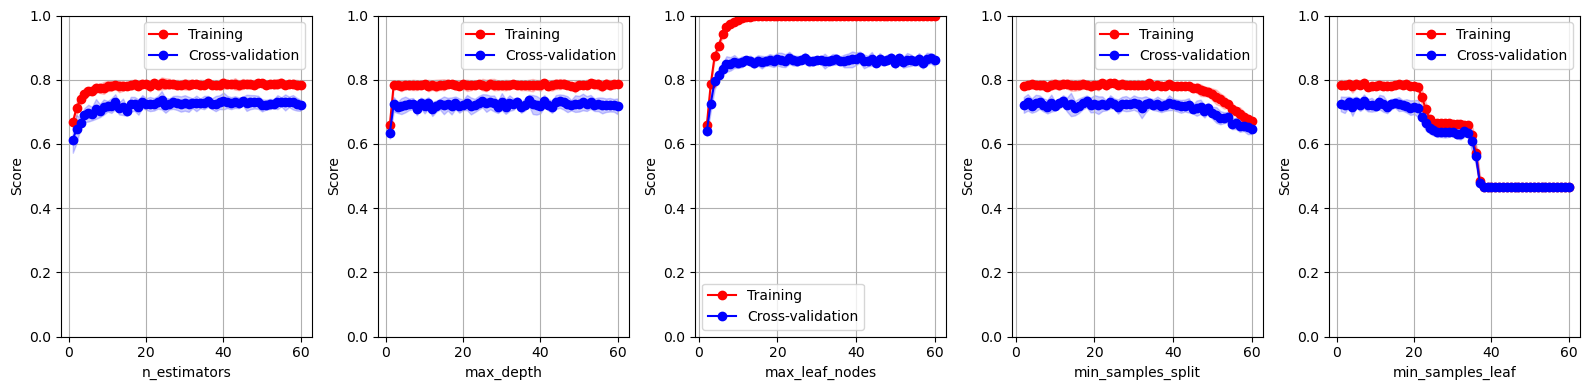

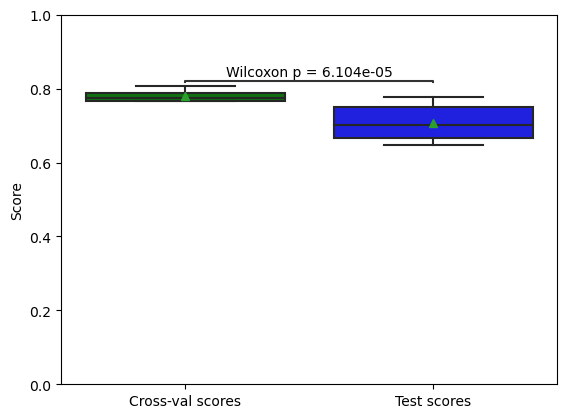

In [ ]:
## FIGURE Mean confusion matrix
fig_mean_CM, ax = plt.subplots()
sns.heatmap(confusion_mat_final, cmap='YlGnBu', vmin=0., vmax=1.,
            xticklabels=[f'Class {i}' for i in range(len(np.unique(y)))],
            yticklabels=[f'Class {i}' for i in range(len(np.unique(y)))],
            ax=ax, annot=True, square=True)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('MEAN Confusion matrix')


## FIGURE Mean ROC-AUC curve and learning curve
mean_learn_train = np.mean(TRAIN_SCORE_MEAN, axis=0)
std_learn_train = np.mean(TRAIN_SCORE_STD, axis=0)
mean_learn_test = np.mean(TEST_SCORE_MEAN, axis=0)
std_learn_test = np.mean(TEST_SCORE_STD, axis=0)

fig_mean_learn, ax_mean_learn = plt.subplots(figsize=(6,4), tight_layout=True)
ax_mean_learn.plot(train_sizes, mean_learn_train, color='r', marker='o', linestyle='--', label='Training')
ax_mean_learn.fill_between(train_sizes,  mean_learn_train-std_learn_train, mean_learn_train+std_learn_train, color='r', alpha=0.2)
ax_mean_learn.plot(train_sizes, mean_learn_test, color='g', marker='o', linestyle='--', label='Cross-validation')
ax_mean_learn.fill_between(train_sizes, mean_learn_test-std_learn_test, mean_learn_test+std_learn_test, color='g', alpha=0.2)
ax_mean_learn.set_ylim(0,1)
ax_mean_learn.set_xlabel('Train set size')
ax_mean_learn.set_ylabel('Score')
ax_mean_learn.grid()
ax_mean_learn.legend()


## FIGURE Mean validation curves
mean_train_val = np.mean(ALL_TRAIN, axis=0)
mean_test_val = np.mean(ALL_VAL, axis=0)
std_train_val = np.std(ALL_TRAIN, axis=0)
std_test_val = np.std(ALL_VAL, axis=0)

k = np.arange(1, len(mean_train_val[0])+1)
fig_mean_val, ax_mean_val = plt.subplots(1, len(mean_train_val), figsize=(16,4), tight_layout=True)
for i in range(len(mean_train_val)):
    ax_mean_val[i].plot(k, mean_train_val[i], color='r', marker='o', label='Training')
    ax_mean_val[i].plot(k, mean_test_val[i], color='b', marker='o', label='Cross-validation')
    ax_mean_val[i].fill_between(k, mean_train_val[i]-std_train_val[i], mean_train_val[i]+std_train_val[i], color='r', alpha=0.2)
    ax_mean_val[i].fill_between(k, mean_test_val[i]-std_test_val[i], mean_test_val[i]+std_test_val[i], color='b', alpha=0.2)
    ax_mean_val[i].set_ylim(0,1)
    ax_mean_val[i].set_xlabel(params_val[i])
    ax_mean_val[i].set_ylabel('Score')
    ax_mean_val[i].grid()
    ax_mean_val[i].legend()
    

## FIGURE Cross-validation scores VS Test scores
df_scores = pd.concat((pd.DataFrame(cross_val_score_all, columns=['Cross-val scores']),
                    pd.DataFrame(test_score_all, columns=['Test scores'])), axis=1)

fig_scores, ax_scores = plt.subplots()
sns.boxplot(data=df_scores, ax=ax_scores, palette=['g','b'], showmeans=True)
add_stat_annotation(data=df_scores, ax=ax_scores, box_pairs = [('Cross-val scores', 'Test scores')], test = 'Wilcoxon', text_format='full')
ax_scores.set_ylabel('Score')
ax_scores.set_ylim(0,1)


#fig_mean_CM.savefig(f'{saving_path}\CM_mean.pdf')
#fig_mean_learn.savefig(f'{saving_path}\Learning_curves.pdf')
#fig_mean_val.savefig(f'{saving_path}\Validation_curves.pdf')
#fig_scores.savefig(f'{saving_path}\CrossVal_and_Test_scores.pdf')